<a href="https://colab.research.google.com/github/gimoonnam/vgg16_practice/blob/main/notebooks/train_on_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Load Modules

In [1]:
import os
import sys
from pathlib import Path

sys.path.append(str(Path(os.getcwd()).resolve()))

from tqdm import tqdm
from torchsummary import summary

import torch
import torch.optim as optim
import torch.nn as nn

from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR

import wandb
from torchsummary import summary

### Mount to Google drive

In [2]:
from google.colab import drive, userdata

if not os.path.exists('/content/drive'):
    drive.mount('/content/drive', force_remount=True)
    print("Drive mounted successfully!")
else:
    print("Drive already mounted.")

Mounted at /content/drive
Drive mounted successfully!


### Clone git and load modules

In [3]:
!git clone https://github.com/gimoonnam/vgg16_practice.git

Cloning into 'vgg16_practice'...
remote: Enumerating objects: 220, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (9/9), done.
remote: Total 220 (delta 1), reused 5 (delta 1), pack-reused 210 (from 1)
Receiving objects: 100% (220/220), 1.83 MiB | 12.02 MiB/s, done.
Resolving deltas: 100% (98/98), done.


In [4]:
repo_path = '/content/vgg16_practice'
if repo_path not in sys.path:
  sys.path.insert(0, repo_path)

from src.utils import split_dataset, EarlyStopping
from models.vgg16 import VGG16
from src.data_classes import TrainingConfig

In [5]:
data_path = r'/content/drive/My Drive/Data for Colab Training'

# CIFAR10 dataset
from torchvision import datasets, transforms

mean = (0.4914, 0.4822, 0.4465)
std = (0.2470, 0.2435, 0.2616)

transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.5,1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# Load from already downloaded dataset (set download=False)
# CIFAR-10 will be in data_path/cifar-10-batches-py/
dataset_train = datasets.CIFAR10(root=data_path, train=True, download=False, transform=transform)
dataset_test = datasets.CIFAR10(root=data_path, train=False, download=False, transform=transform)

print(f"Training samples: {len(dataset_train)}")
print(f"Test samples: {len(dataset_test)}")

Training samples: 50000
Test samples: 10000


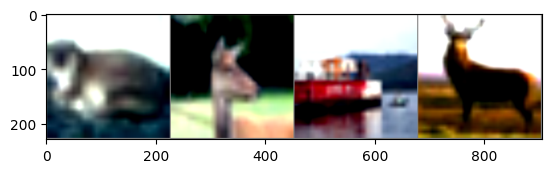

cat   deer  ship  deer 


In [6]:
import numpy as np
import matplotlib.pyplot as plt

import torchvision
def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()

trainloader = DataLoader(dataset_train, batch_size=4, shuffle=True)

# 학습용 이미지를 무작위로 가져오기
dataiter = iter(trainloader)
images, labels = next(dataiter)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

NUM_CLASSES = len(classes)

# 이미지 보여주기
imshow(torchvision.utils.make_grid(images))
# 정답(label) 출력
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))


In [7]:
train_dataset, val_dataset = split_dataset(dataset_train, train_ratio=0.8)

# Configuration for training
config = TrainingConfig(
    batch_size=64,
    num_epochs=20,
    num_train_samples=len(train_dataset),  # Set from your dataset
    lr_scheduler_epoch=10,
    learning_rate=1e-3,
    weight_decay=1e-4,
    save_path=r"/Users/gimoon/Documents/GitHub/vgg16_practice/checkpoints"
)
# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=config.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.batch_size, shuffle=False)

print(f"\nTrain batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Training set size: 40000
Validation set size: 10000

Train batches: 625
Validation batches: 157


### Load VGG16 model

In [8]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# from torchvision import models

# load pretrained VGG16 model from torchvision, where weights='default' uses pretrained weights on ImageNet1K_V1
# model = models.vgg16(weights='DEFAULT')

# # freeze all layers first
# for param in model.parameters():
#     param.requires_grad = False

# # unfreeze the last layer of the classifier
# model.classifier[3].requires_grad_ = True

# # customize the last layer of the classifier to match the number of classes
# model.classifier[6] = nn.Sequential(
#                       nn.Linear(4096, 512),
#                       nn.ReLU(),
#                       nn.Dropout(0.5),
#                       nn.Linear(512, NUM_CLASSES))

# model = model.to(device)
# model.classifier

# summary(model, (3, 224, 224))


In [9]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# from torchvision import models

# # load pretrained VGG16 model from torchvision, where weights='default' uses pretrained weights on ImageNet1K_V1
# # model = models.vgg16(weights='DEFAULT')

# model = models.resnet18(weights='IMAGENET1K_V1')

# # freeze all layers first
# for param in model.parameters():
#     param.requires_grad = False

# num_ftrs = model.fc.in_features
# # Here the size of each output sample is set to 2.
# # Alternatively, it can be generalized to ``nn.Linear(num_ftrs, len(class_names))``.
# model.fc = nn.Linear(num_ftrs, NUM_CLASSES)
# model.fc.requires_grad = True

# model = model.to(device)
# # summary(model, (3, 224, 224))
# model.fc


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = VGG16(num_classes=NUM_CLASSES)
model = model.to(device)

summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 224, 224]           1,792
       BatchNorm2d-2         [-1, 64, 224, 224]             128
              ReLU-3         [-1, 64, 224, 224]               0
            Conv2d-4         [-1, 64, 224, 224]          36,928
       BatchNorm2d-5         [-1, 64, 224, 224]             128
              ReLU-6         [-1, 64, 224, 224]               0
         MaxPool2d-7         [-1, 64, 112, 112]               0
            N_conv-8         [-1, 64, 112, 112]               0
            Conv2d-9        [-1, 128, 112, 112]          73,856
      BatchNorm2d-10        [-1, 128, 112, 112]             256
             ReLU-11        [-1, 128, 112, 112]               0
           Conv2d-12        [-1, 128, 112, 112]         147,584
      BatchNorm2d-13        [-1, 128, 112, 112]             256
             ReLU-14        [-1, 128, 1

In [11]:
from datetime import datetime
import pytz

# lr_scheduler_step_size = config.lr_scheduler_step_size()
# print(lr_scheduler_step_size)

# total_steps = config.total_steps()
# print(total_steps)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), momentum=0.9, lr=config.learning_rate)#, weight_decay=config.weight_decay)
# scheduler = StepLR(optimizer, step_size=config.lr_scheduler_epoch, gamma=0.5)

optimizer_name = type(optimizer).__name__
print(optimizer_name)


asia_tz = pytz.timezone("Asia/Seoul")
saved_time = datetime.now(asia_tz).strftime("%Y-%m-%d %H:%M:%S")
run_name = f"checkpoint_CIFAR10_fromScratch_augmentation_{saved_time}"

print(run_name)

checkpoint_path = r'/content/drive/My Drive/checkpoints'
checkpoint_file = os.path.join(checkpoint_path, f"{run_name}.pth.tar")

early_stopping = EarlyStopping(patience=5, verbose=True, path=checkpoint_file)

SGD
checkpoint_CIFAR10_fromScratch_augmentation_2026-03-05 09:11:31


### Configuring WandB

In [12]:
os.environ["WANDB_API_KEY"] = userdata.get('wandb_key')
wandb.login()

# Start a new wandb run to track this script.
run = wandb.init(
    # Set the wandb entity where your project will be logged (generally your team name).
    entity="gimoonnam",
    # Set the wandb project where this run will be logged.
    project="vgg16_practice",
    # Track hyperparameters and,
    name = run_name,

    config={
        "learning_rate": config.learning_rate,
        "architecture": "CNN",
        "dataset": "CIFAR-10",
        "epochs": config.num_epochs,
    },
)

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: gimoonnam to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


### Training along with validating

In [13]:
# curr_lr = scheduler.get_last_lr()[0]

from src.utils import compute_accuracy, compute_epoch_loss, calc_accuracy_loader


for epoch in range(config.num_epochs):
    # ==================== TRAINING ====================
    model.train()
    epoch_train_loss = 0.0

    ProgressBar = tqdm(enumerate(train_loader), total=len(train_loader))

    for batch_idx, (inputs, labels) in ProgressBar:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(inputs)

        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        epoch_train_loss += loss.item()

        # Update Progress bar (only training loss during training)
        ProgressBar.set_description(f'Epoch [{epoch+1}/{config.num_epochs}]')
        ProgressBar.set_postfix(TrainLoss=loss.item())

    # Average training loss for the epoch
    avg_train_loss = epoch_train_loss / len(train_loader)

    # ==================== VALIDATION (Once per epoch) ====================
    print(f"\nRunning validation for epoch {epoch+1}...")
    with torch.no_grad():
        avg_val_acc = compute_accuracy(model, val_loader, device)
        avg_val_loss = compute_epoch_loss(model, val_loader, criterion, device)

    # Print epoch summarywjs
    print(f"\nEpoch {epoch+1} Summary:")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {avg_val_loss:.4f}")
    print(f"  Val Acc:    {avg_val_acc:.4f}")

    # Update learning rate scheduler
    # scheduler.step()
    # curr_lr = scheduler.get_last_lr()[0]


    # Log metrics to wandb (once per epoch)
    run.log({
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,
        "val_accuracy": avg_val_acc,
    })

    # Check early stopping
    early_stopping(avg_val_loss, model)
    if early_stopping.early_stop:
        print("Early stopping triggered. Training halted.")
        break


run.finish()

Epoch [1/20]: 100%|██████████| 625/625 [02:31<00:00,  4.13it/s, TrainLoss=1.45]



Running validation for epoch 1...

Epoch 1 Summary:
  Train Loss: 1.7713
  Val Loss:   0.0233
  Val Acc:    0.4501
Validation loss decreased (inf --> 0.023301). Saving model...


Epoch [2/20]: 100%|██████████| 625/625 [02:31<00:00,  4.12it/s, TrainLoss=1.39]



Running validation for epoch 2...

Epoch 2 Summary:
  Train Loss: 1.4659
  Val Loss:   0.0214
  Val Acc:    0.5027
Validation loss decreased (0.023301 --> 0.021403). Saving model...


Epoch [3/20]: 100%|██████████| 625/625 [02:32<00:00,  4.11it/s, TrainLoss=1.15]


...

Epoch [19/20]: 100%|██████████| 625/625 [02:32<00:00,  4.10it/s, TrainLoss=0.439]



Running validation for epoch 19...

Epoch 19 Summary:
  Train Loss: 0.5262
  Val Loss:   0.0098
  Val Acc:    0.7878
EarlyStopping counter: 1 out of 5


Epoch [20/20]: 100%|██████████| 625/625 [02:31<00:00,  4.12it/s, TrainLoss=0.608]



Running validation for epoch 20...

Epoch 20 Summary:
  Train Loss: 0.5150
  Val Loss:   0.0097
  Val Acc:    0.7867
EarlyStopping counter: 2 out of 5


train_loss,█▆▅▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁
val_accuracy,▁▂▃▄▅▅▅▆▇▇▇▇▇█▇▇████
val_loss,█▇▆▅▄▄▄▄▂▂▂▃▂▁▂▂▁▁▁▁
train_loss,0.51499
val_accuracy,0.7867
val_loss,0.00975


In [14]:
# from models.vgg16 import save_checkpoint, load_checkpoint

checkpoint_path = r'/content/drive/My Drive/checkpoints'

checkpoint = {
    "batch_size": config.batch_size,
    "epoch": epoch,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
}

save_pth = os.path.join(checkpoint_path, f"{run_name}.pth.tar")
print(save_pth)
torch.save(checkpoint, save_pth)

# pth_file_path = os.path.join(checkpoint_path, 'checkpoint-2026-02-12 09_10_08.pth')
# model, optimizer, epoch, loss = load_checkpoint(pth_file_path, model, optimizer)

/content/drive/My Drive/checkpoints/checkpoint_CIFAR10_fromScratch_augmentation_2026-03-05 09:11:31.pth.tar


In [15]:
@torch.no_grad()  # Disable gradient tracking for efficiency
def calc_accuracy_loader(data_loader, model, device, num_batches=None, desc='testing'):
    model.eval()
    correct_predictions, num_examples = 0, 0

    if num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))

    for i, (input_batch, target_batch) in enumerate(tqdm(data_loader, desc)):
        if i < num_batches:
            input_batch, target_batch = input_batch.to(device), target_batch.to(device)
            logits = model(input_batch)
            predicted_labels = torch.argmax(logits, dim=1)
            num_examples += predicted_labels.shape[0]
            correct_predictions += (predicted_labels == target_batch).sum().item()
        else:
            break
    return correct_predictions / num_examples

In [16]:


test_loader = DataLoader(dataset_test, batch_size=config.batch_size, shuffle=False)

calc_accuracy_loader(test_loader, model, device, config.batch_size )

testing:  41%|████      | 64/157 [00:08<00:12,  7.17it/s]


0.778564453125